### Importando as Bases e Bibliotecas

base de dados: Brazilian E-Commerce Public Dataset by Olist.

é uma base de dados de pedidos de um e-commerce brasileiro, separadas em alguns arquivos em csv, cada um dos arquivos csv contem informações importantes que vou usar pra responder algumas perguntas.

In [ ]:
import pandas as  pd #pd é um apelido muito usado pro pandas, que vai ser nossa principal biblioteca pra analisar as bases de dados
import matplotlib.pyplot as plt #plt também é um apelido muito usado pro matplotlib, nossa biblioteca para trabalhar com gráficos

tabelaclientes = pd.read_csv("olist_customers_dataset.csv") #importando as bases de dados do dataset usando o nome dos arquivos de cada base

tabelalocalizaçoes = pd.read_csv("olist_geolocation_dataset.csv")

tabelainfopedidos = pd.read_csv("olist_order_items_dataset.csv")

tabelapagamentos = pd.read_csv("olist_order_payments_dataset.csv")

tabelaavaliaçoes = pd.read_csv("olist_order_reviews_dataset.csv")

tabelapedidos = pd.read_csv("olist_orders_dataset.csv")

tabelaprodutos = pd.read_csv("olist_products_dataset.csv")

tabelavendedores = pd.read_csv("olist_sellers_dataset.csv")

tabelacategoriaprodutos = pd.read_csv("product_category_name_translation.csv")

display(tabelainfopedidos) #exibindo as tabelas pra ter uma visualização do conteúdo

### Quais produtos geraram mais faturamento?

pra saber quais produtos geram mais faturamento vou analisar tabelas que podem me dar essa informação, rodando a primeira celula de codigo e só trocando qual tabela vou exibir com o display até achar informações importantes.

In [ ]:
produtosquemaisfaturam = tabelainfopedidos[["product_id", "price", "freight_value"]].merge(tabelaprodutos[["product_id", "product_category_name"]], on="product_id") #a tabela infopedidos nos dá 3 informções importantes, o preço, valor do frete e id do produto, por isso separei elas em outro dataframe
produtosquemaisfaturam = produtosquemaisfaturam.groupby(["product_id", "product_category_name"]).sum() #os itens da coluna product_id passam a aparecer só uma vez, e os preços são somados em cada coluna restante

produtosquemaisfaturam["total_value"] = produtosquemaisfaturam["price"] + produtosquemaisfaturam["freight_value"] #criando uma nova coluna com o valor dos preços totais de cada produto (soma do preço e valor do frete)
produtosquemaisfaturam = produtosquemaisfaturam[["total_value"]].sort_values(by="total_value", ascending= False) #excluindo as outras colunas já que não são relevantes mais e ordenando os valores totais dos produtos do maior para o menor
produtosquemaisfaturam = produtosquemaisfaturam[:10] #selecionando só os 10 produtos que mais faturaram 
produtosquemaisfaturam = produtosquemaisfaturam.reset_index() #product id passa a seruma coluna normal, sem estar no index, facilitando algumas analises
display(produtosquemaisfaturam)

agora vou exibir as informações que consegui usando um gráfico feito com matplotllib.

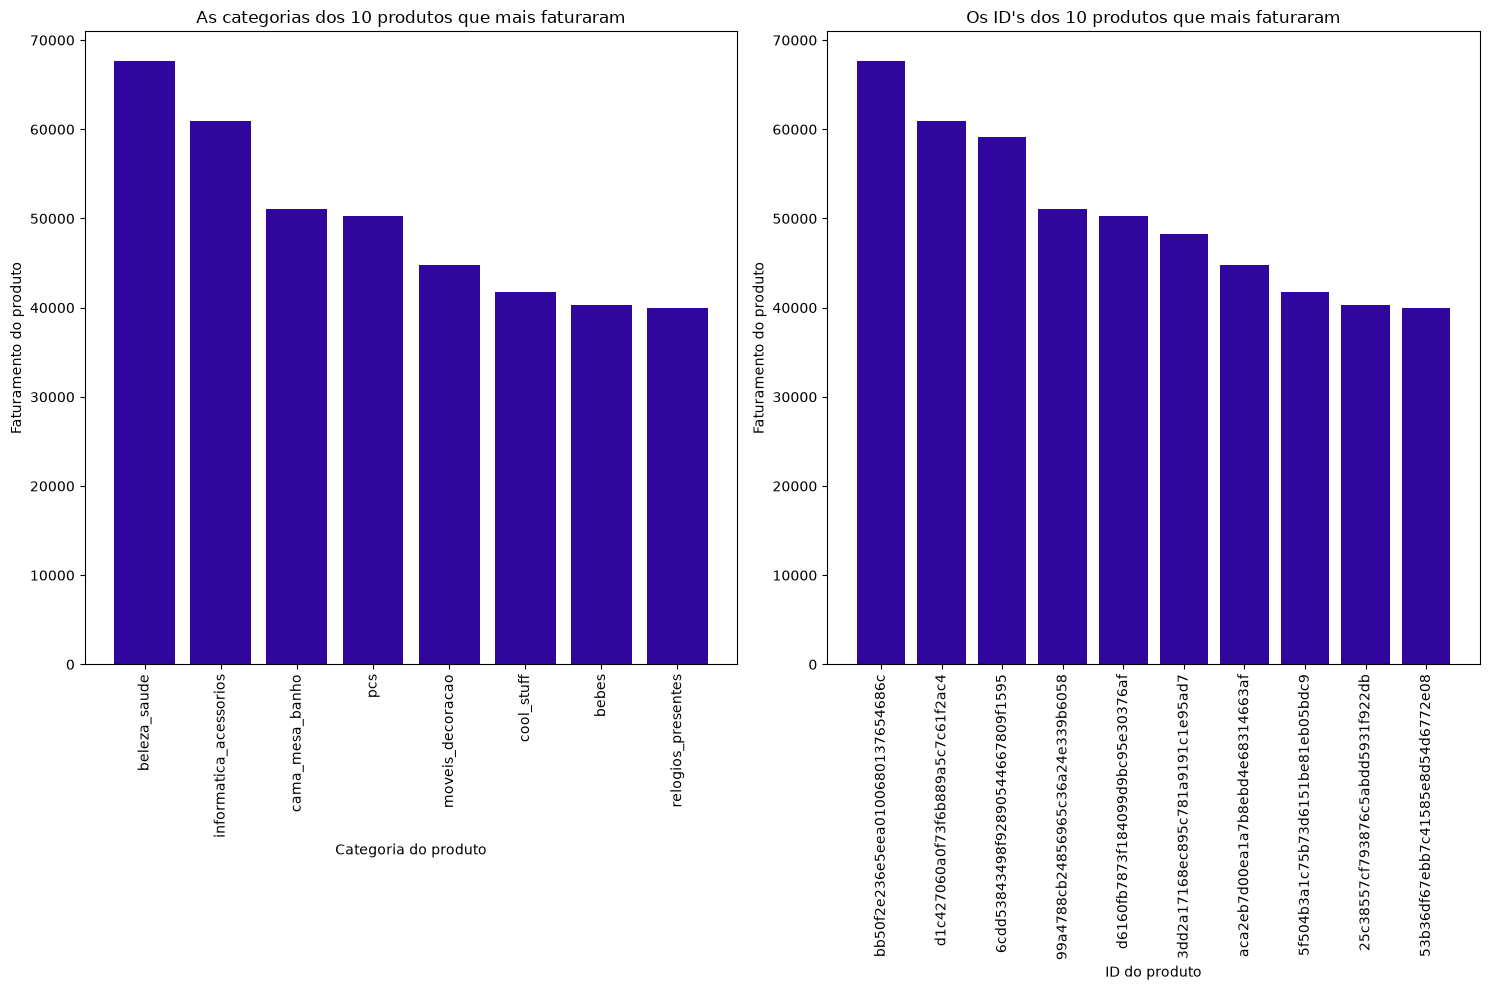

In [ ]:
fig, ax =  plt.subplots(1, 2, figsize=(15, 10)) #criando  os dois graficos juntos pra eles aparecerem um do lado do outro e não um em cima do outro

ax[0].bar(produtosquemaisfaturam["product_category_name"], produtosquemaisfaturam["total_value"], color="#2F079C") #colocando as informações necessárias no gráfico 

ax[0].set_title("As categorias dos 10 produtos que mais faturaram") #o titulo do gráfico
ax[0].set_xlabel("Categoria do produto") #o que aparece no eixo X do gráfico (horizontal)
ax[0].set_ylabel("Faturamento do produto") #o que aparece no eixo Y do gráfico (vertical)

ax[0].tick_params(axis="x", rotation=90) #girando o eixo X(categoria  do produto) pra facilitar a visualização



ax[1].bar(produtosquemaisfaturam["product_id"], produtosquemaisfaturam["total_value"], color="#2F079C") #pro segundo gráfico exatamente o mesmo processo mas com a coluna de ID's da nossa basse

ax[1].set_title("Os ID's dos 10 produtos que mais faturaram")
ax[1].set_xlabel("ID do produto")
ax[1].set_ylabel("Faturamento do produto")

ax[1].tick_params(axis="x", rotation=90)

plt.tight_layout() #tornando os gráficos mais compactos, para que um não fique por cima do outro ou para que as informações não fiquem umas por cima das outras
plt.show() #exibindo os gráficos

### Quais produtos venderam mais em quantidade?

novamente vou analisar as tabelas e pegar as informações importantes.

In [60]:
produtosecategoriasdospedidos  = tabelainfopedidos[["product_id"]].merge(tabelaprodutos[["product_id", "product_category_name"]], on="product_id") #criando uma tabela com as categorias e ID's dos produtos de cada pedido
produtosmaisvendidos = produtosecategoriasdospedidos.value_counts().reset_index() #uso o value counts pra contar quantas vezes cada produto apareceu na tabela de pedidos, isso me dá a quantidade de vendas dele
produtosmaisvendidos = produtosmaisvendidos[:10] #escolho só os 10 produtos mais vendidos pra deixar na tabela

display(produtosmaisvendidos) #resultado final 

,product_id,product_category_name,count
0,aca2eb7d00ea1a7b8ebd4e68314663af,moveis_decoracao,527
1,99a4788cb24856965c36a24e339b6058,cama_mesa_banho,488
2,422879e10f46682990de24d770e7f83d,ferramentas_jardim,484
3,389d119b48cf3043d311335e499d9c6b,ferramentas_jardim,392
4,368c6c730842d78016ad823897a372db,ferramentas_jardim,388
5,53759a2ecddad2bb87a079a1f1519f73,ferramentas_jardim,373
6,d1c427060a0f73f6b889a5c7c61f2ac4,informatica_acessorios,343
7,53b36df67ebb7c41585e8d54d6772e08,relogios_presentes,323
8,154e7e31ebfa092203795c972e5804a6,beleza_saude,281
9,3dd2a17168ec895c781a9191c1e95ad7,informatica_acessorios,274


agora vou exibir os graficos com os ID's e Categorias dos produtos que mais venderam em quantidade.

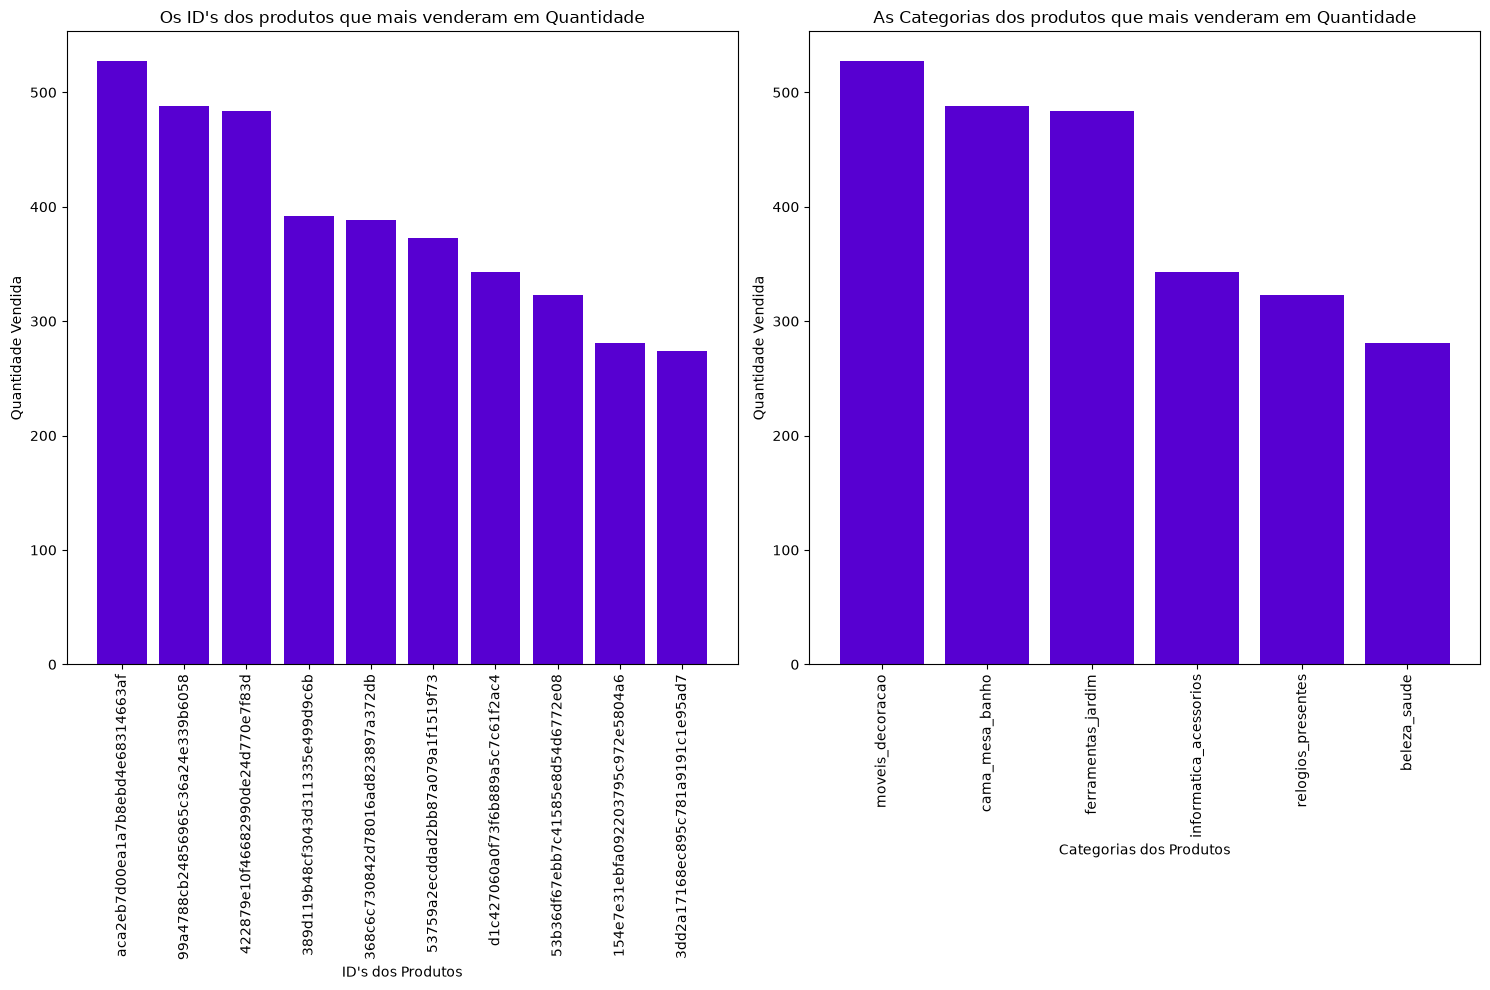

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(15, 10)) #criando  os dois graficos juntos pra eles aparecerem um do lado do outro e não um em cima do outro

ax[0].bar(produtosmaisvendidos["product_id"], produtosmaisvendidos["count"], color="#5700D1") #colocando as informações do gráfico

ax[0].set_title("Os ID's dos produtos que mais venderam em Quantidade") #o título do gráfico
ax[0].set_xlabel("ID's dos Produtos") #descrição do que aparece na horizontal do gráfico
ax[0].set_ylabel("Quantidade Vendida") #descrição do que aparece na vertical do gráfico

ax[0].tick_params(axis="x", rotation=90) #girando a legenda horizontal pra facilitar a visualização



ax[1].bar(produtosmaisvendidos["product_category_name"], produtosmaisvendidos["count"], color="#5700D1") #o mesmo processo para o próximo gráfico, mudando só as informações exibidas

ax[1].set_title("As Categorias dos produtos que mais venderam em Quantidade")
ax[1].set_xlabel("Categorias dos Produtos")
ax[1].set_ylabel("Quantidade Vendida")

ax[1].tick_params(axis="x", rotation=90)

plt.tight_layout() #tornando os gráficos mais compactos, para que um não fique por cima do outro ou para que as informações não fiquem umas por cima das outras
plt.show() #exibindo os gráficos